In [34]:
%load_ext autoreload
%autoreload 2
import main
import numpy as np

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Parameters

In [15]:
rho = 1
d_list = [100, 200, 400]
num_runs = 10
num_epochs = 100
sigma2 = 0.01

## Experiment 1 : Figuring out scaling on $\gamma$ in small batch SGD

### Without optimizing for the absolute cst

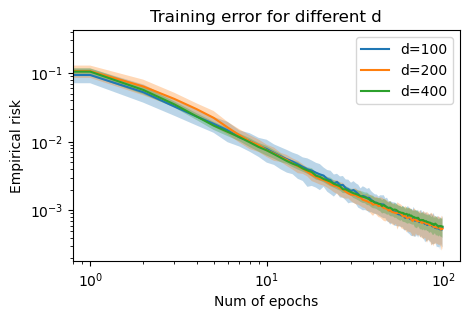

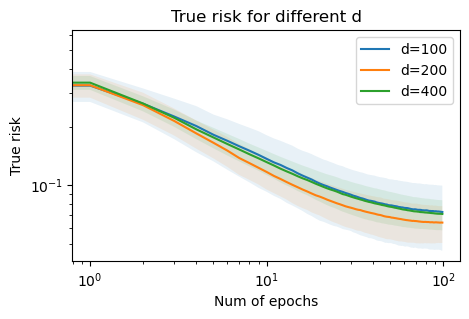

In [14]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.run_sgd, gamma=lambda d:d, sigma_hat=lambda d:np.eye(d)) 

### Setting the absolute constant to $ \frac{1}{\lambda_{max} (A^T A)} $

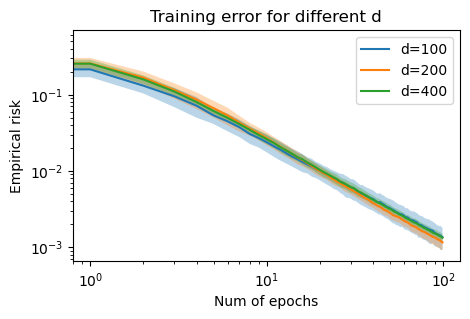

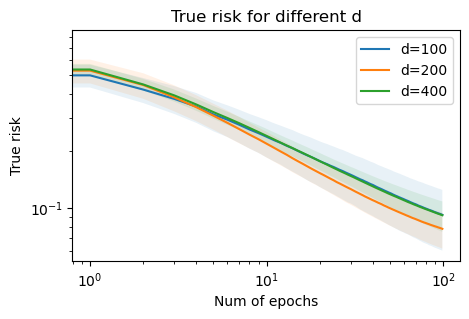

In [4]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.run_sgd, gamma=lambda d:d, sigma_hat=lambda d:np.eye(d), step_type="max") 

### Setting the absolute constant to $ \frac{1}{\lambda_{avg} (A^T A)} $

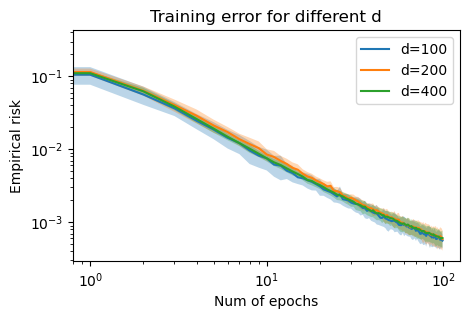

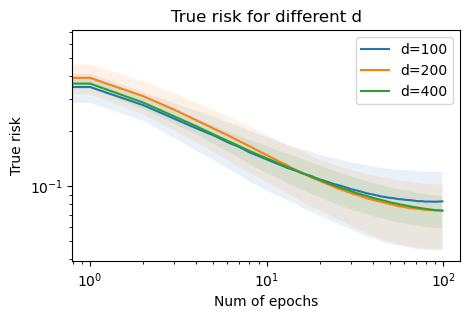

In [5]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.run_sgd, gamma=lambda d:d, sigma_hat=lambda d:np.eye(d), step_type="avg")

### Different covariance structures

In [19]:
cov_structures = {
    "identity": lambda d: np.eye(d),
    "diag_decreasing": lambda d: np.diag(np.linspace(1, 0.1, d)),
    "diag_increasing": lambda d: np.diag(np.linspace(0.1, 2, d)),
    "toeplitz": lambda d: np.array([[0.9**abs(i-j) for j in range(d)] for i in range(d)]),
    "low_rank": lambda d: (np.random.randn(d, 5) @ np.random.randn(5, d))
}

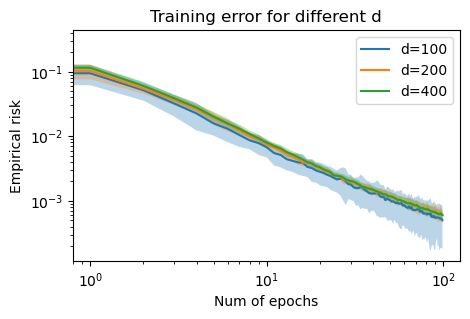

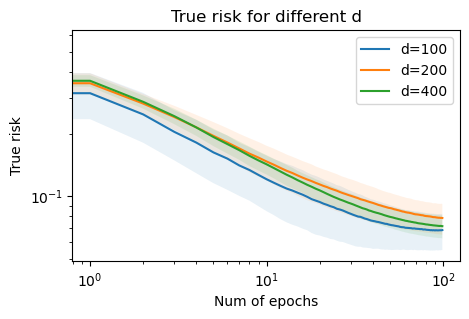

In [12]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.run_sgd, gamma=lambda d:d, sigma_hat=cov_structures["identity"], step_type="mean") 

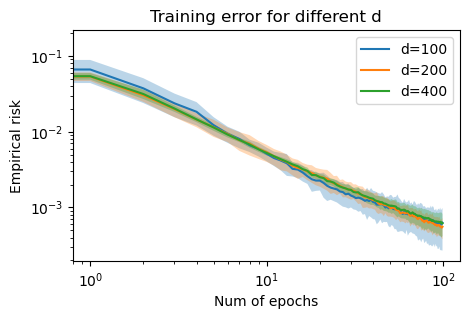

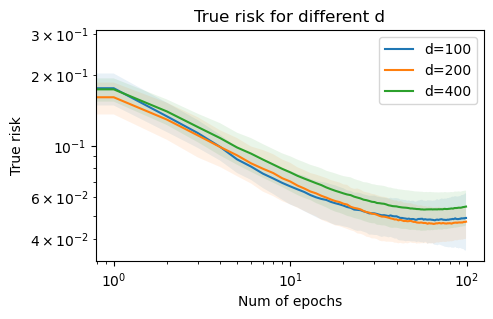

In [8]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.run_sgd, gamma=lambda d:d, sigma_hat=cov_structures["diag_decreasing"], step_type="avg") 

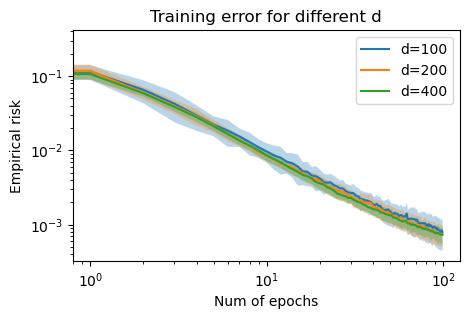

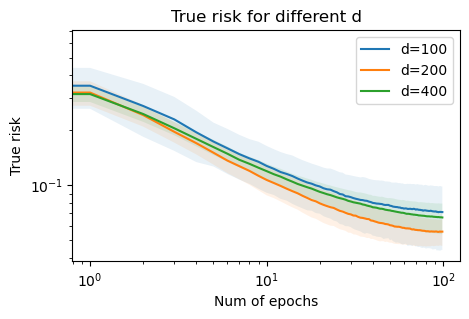

In [9]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.run_sgd, gamma=lambda d:d, sigma_hat=cov_structures["diag_increasing"], step_type="avg") 

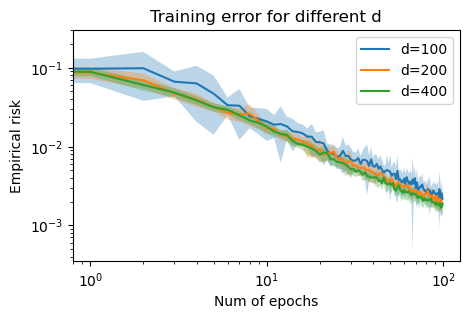

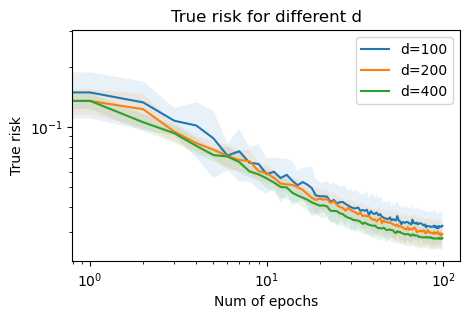

In [10]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.run_sgd, gamma=lambda d:d, sigma_hat=cov_structures["toeplitz"], step_type="avg") 

## Experiment 2 : Effect of randomness in SGD

### Single shuffle sgd

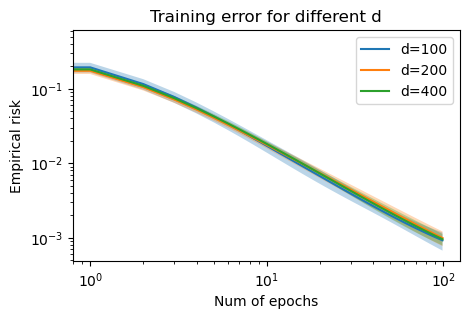

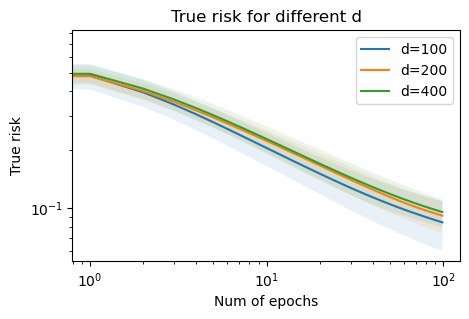

In [51]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.single_suffle_sgd, gamma=lambda d:d, sigma_hat=cov_structures["identity"], step_type="max") 

### Multiple shuffle sgd

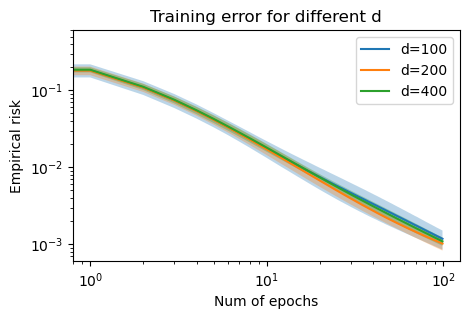

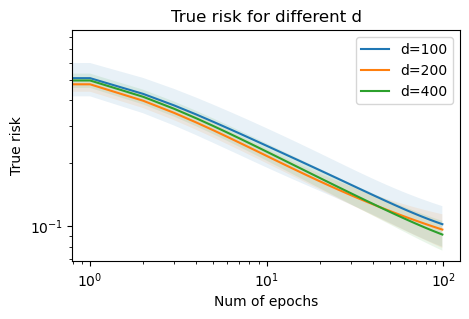

In [52]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.multiple_suffle_sgd, gamma=lambda d:d, sigma_hat=cov_structures["identity"], step_type="max") 

## Experiment 3 : SGD with momentum

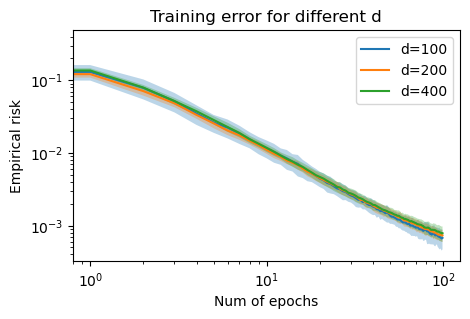

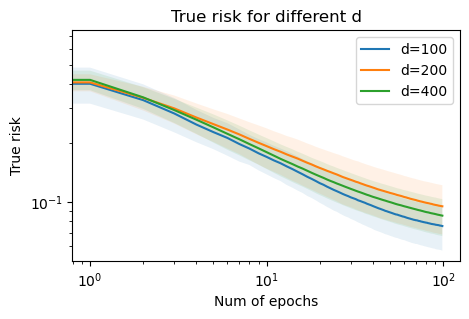

In [46]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.sgd_momentum_fixed_delta, gamma=lambda d:d, sigma_hat=cov_structures["identity"], step_type="max")